In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import seaborn as sns
import os


In [2]:
df = pd.read_csv("../Data/Historical Product Demand.csv")


In [3]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  object
dtypes: object(5)
memory usage: 40.0+ MB


In [5]:
df.isnull().sum()

Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64

In [6]:
df.describe()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
count,1048575,1048575,1048575,1037336,1048575
unique,2160,4,33,1729,3828
top,Product_1359,Whse_J,Category_019,2013/9/27,1000
freq,16936,764447,481099,2075,112682


In [7]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [8]:
df.sample(5)

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
444065,Product_0050,Whse_J,Category_005,2014/3/10,100
9333,Product_1195,Whse_C,Category_019,2012/6/20,13000
626663,Product_0827,Whse_J,Category_008,2014/11/14,123
860022,Product_0889,Whse_C,Category_023,2016/10/3,350
429317,Product_0261,Whse_S,Category_001,2014/5/27,5


In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 926152 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Product_Code      926152 non-null  object        
 1   Warehouse         926152 non-null  object        
 2   Product_Category  926152 non-null  object        
 3   Date              924272 non-null  datetime64[ns]
 4   Order_Demand      926152 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 42.4+ MB


In [11]:
df['Order_Demand'] = pd.to_numeric(df['Order_Demand'], errors='coerce')

print("NaN in Order_Demand" , df["Order_Demand"].isnull().sum())
print("NaN in Date" , df["Date"].isnull().sum())

NaN in Order_Demand 6798
NaN in Date 1880


In [12]:
df.dropna(subset=['Date'], inplace=True)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 924272 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Product_Code      924272 non-null  object        
 1   Warehouse         924272 non-null  object        
 2   Product_Category  924272 non-null  object        
 3   Date              924272 non-null  datetime64[ns]
 4   Order_Demand      918468 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 42.3+ MB


In [14]:
# รีเซ็ต Index ให้เรียงลำดับใหม่ตั้งแต่ 0 อย่างสวยงาม
df.reset_index(drop=True, inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924272 entries, 0 to 924271
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Product_Code      924272 non-null  object        
 1   Warehouse         924272 non-null  object        
 2   Product_Category  924272 non-null  object        
 3   Date              924272 non-null  datetime64[ns]
 4   Order_Demand      918468 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 35.3+ MB


In [16]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek # 0=จันทร์, 6=อาทิตย์

In [17]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand,Year,Month,DayOfWeek
0,Product_0993,Whse_J,Category_028,2012-07-27,100.0,2012,7,4
1,Product_0979,Whse_J,Category_028,2012-01-19,500.0,2012,1,3
2,Product_0979,Whse_J,Category_028,2012-02-03,500.0,2012,2,4
3,Product_0979,Whse_J,Category_028,2012-02-09,500.0,2012,2,3
4,Product_0979,Whse_J,Category_028,2012-03-02,500.0,2012,3,4


In [18]:
df['Order_Demand'].describe()

count    9.184680e+05
mean     5.135949e+03
std      3.050339e+04
min      0.000000e+00
25%      2.000000e+01
50%      3.000000e+02
75%      2.000000e+03
max      4.000000e+06
Name: Order_Demand, dtype: float64

สรุปสิ่งที่พบจากข้อมูล:
- mean(5135) and median(300) ต่างกันเยอะมาก ลูกค้าส่วนใหญ่สั่งแค่ไม่เกิน 300 ชิ้น แต่มีลูกค้าลาบใหญ่สั่ง 4000000 ดึง mean ทำให้ mean เชื่อไม่ได้

- outliers Max(4,000,000) ห่างจาก Median(300) ถ้าเอาไป Train Model เลย Model เพี้ยน

- std สูง  std(30,503) สูงกว่า mean(5135) หลายเท่าตัว ยอดสั่งซื้อในแต่ละวัน "ไม่นิ่งเลย"

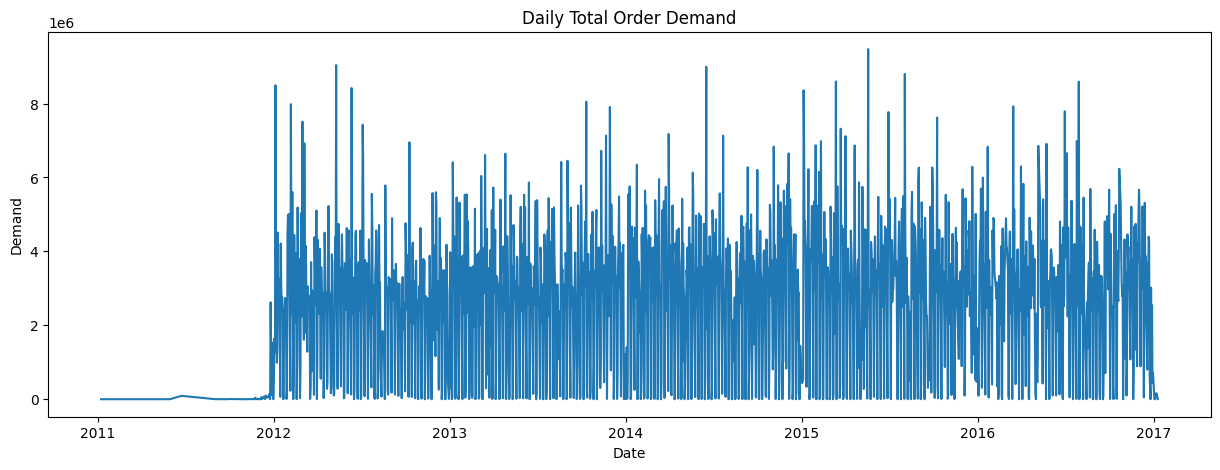

In [ ]:
# รวมยอด Order_Demand เป็นรายวัน 
# (คุณสามารถเพิ่ม Product_Code เข้าไปใน groupby ได้ถ้าต้องการดูยอดแยกตามสินค้า)
daily_demand = df.groupby('Date')['Order_Demand'].sum().reset_index()

# ลองพล็อตดูลูกคลื่นของความต้องการสินค้าเบื้องต้น
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(daily_demand['Date'], daily_demand['Order_Demand'])
plt.title('Daily Total Order Demand')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.show()

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

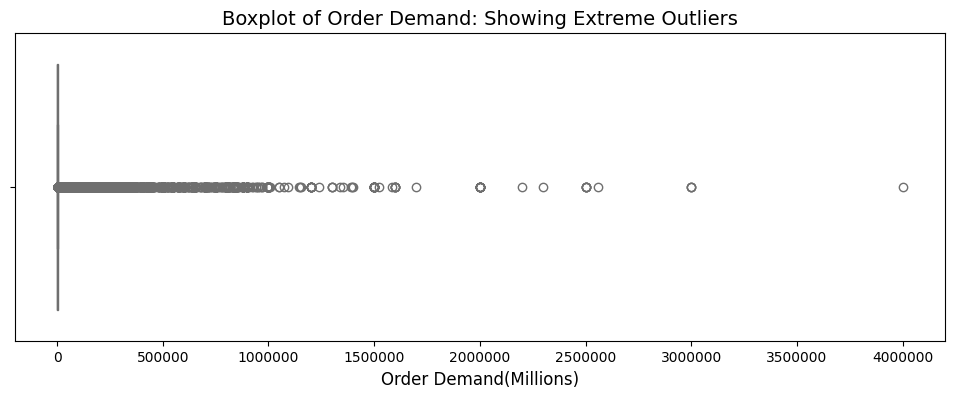

In [21]:
plt.figure(figsize=(12,4))
sns.boxplot(x=df['Order_Demand'], color='skyblue')

plt.title('Boxplot of Order Demand: Showing Extreme Outliers', fontsize=14)
plt.xlabel('Order Demand(Millions)', fontsize=12)

# ปรับฟอร์แมตแกน X ไม่ให้เป็นตัวเลขวิทยาศาสตร์ (e) เพื่อให้ดูง่ายขึ้น
plt.ticklabel_format(style='plain', axis='x')
plt.show()

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Gl

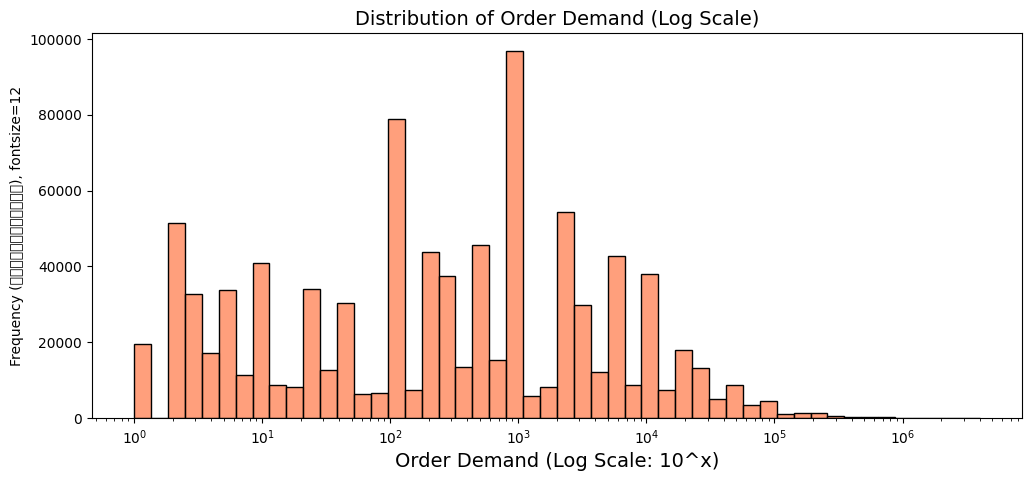

In [22]:
plt.figure(figsize=(12,5))

# เราบวก 1 เข้าไปตอนทำ Log เพื่อป้องกัน Error จากกรณีออเดอร์เป็น 0 (log(0) หาค่าไม่ได้)
sns.histplot(df['Order_Demand'] + 1, bins=50, log_scale=True, color='coral')

plt.title('Distribution of Order Demand (Log Scale)', fontsize=14)
plt.xlabel("Order Demand (Log Scale: 10^x)", fontsize=14)
plt.ylabel('Frequency (จำนวนออเดอร์), fontsize=12')
plt.show()

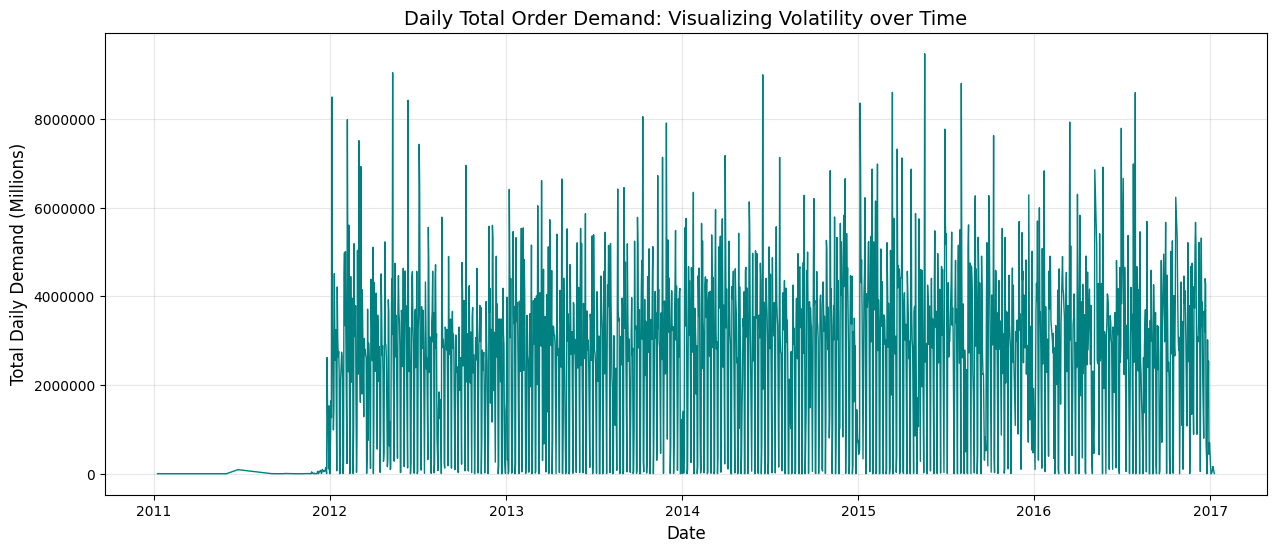

In [23]:
#line chart

daily_demand = df.groupby('Date')['Order_Demand'].sum().reset_index()

plt.figure(figsize=(15,6))
plt.plot(daily_demand['Date'], daily_demand['Order_Demand'], color='teal', linewidth=1)

plt.title('Daily Total Order Demand: Visualizing Volatility over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Daily Demand (Millions)', fontsize=12)

plt.ticklabel_format(style='plain', axis='y') 
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
zero_demand_count = (df['Order_Demand'] == 0).sum()
print(zero_demand_count)

19639


In [25]:
df = df[df['Order_Demand'] > 0]

In [26]:
top_10_demand = df.sort_values(by='Order_Demand', ascending=False).head(10)
top_10_demand

,Product_Code,Warehouse,Product_Category,Date,Order_Demand,Year,Month,DayOfWeek
20202,Product_1432,Whse_S,Category_019,2012-06-11,4000000.0,2012,6,0
67022,Product_1341,Whse_C,Category_019,2012-02-06,3000000.0,2012,2,0
19795,Product_1248,Whse_J,Category_019,2012-07-05,3000000.0,2012,7,3
198105,Product_1432,Whse_S,Category_019,2013-06-14,3000000.0,2013,6,4
230938,Product_1248,Whse_J,Category_019,2013-11-11,2560000.0,2013,11,0
97618,Product_1248,Whse_J,Category_019,2012-11-26,2500000.0,2012,11,0
579195,Product_1432,Whse_S,Category_019,2015-10-09,2500000.0,2015,10,4
767072,Product_1432,Whse_S,Category_019,2016-07-29,2500000.0,2016,7,4
579190,Product_1432,Whse_S,Category_019,2015-05-19,2500000.0,2015,5,1
579186,Product_1432,Whse_S,Category_019,2015-03-13,2500000.0,2015,3,4


In [27]:
#เช็คว่า Outliers หลักล้าน มาจาก "สินค้ากลุ่มเดียวกัน" หรือไม่
outliners_df = df[df['Order_Demand'] >= 100000]
print(outliners_df['Product_Code'].value_counts().head())

print(outliners_df['Product_Category'].value_counts())

Product_Code
Product_1359    1033
Product_1248     794
Product_1341     621
Product_0083     308
Product_1241     307
Name: count, dtype: int64
Product_Category
Category_019    7194
Category_006     683
Category_007     439
Category_005     116
Category_033      89
Category_028      37
Category_030      11
Category_032       1
Name: count, dtype: int64


In [28]:
df['Product_Category'].value_counts()

Product_Category
Category_019    386064
Category_005     90439
Category_001     83630
Category_007     72219
Category_021     49110
Category_006     32346
Category_028     27294
Category_015     21983
Category_011     21271
Category_024     19880
Category_009     18978
Category_026     13659
Category_030     12533
Category_032      8969
Category_022      8404
Category_023      7230
Category_018      4973
Category_003      3937
Category_013      3588
Category_020      3309
Category_031      2126
Category_033      1688
Category_008      1494
Category_012      1088
Category_010       916
Category_029       622
Category_017       583
Category_004       303
Category_002        74
Category_016        37
Category_025        35
Category_014        26
Category_027        21
Name: count, dtype: int64

Category_019 เหมาสัดส่วนออเดอร์ทะลุแสนไปถึง 7,194 ครั้ง ตัดทิ้งไม่ดี

In [29]:
#Step 1: จัดการ Outlier "แยกตาม Category" (Local Capping)
df['Demand_Capped'] = df.groupby('Product_Category')['Order_Demand'].transform(lambda x: x.clip(upper=x.quantile(0.98)))

print("Max Demand (Original):", df['Order_Demand'].max())
print("Max Demand (Capped):", df['Demand_Capped'].max())

Max Demand (Original): 4000000.0
Max Demand (Capped): 100000.0


In [30]:
#Step 2: Aggregation (รวมยอดเป็นรายสัปดาห์)
df_time = df.set_index('Date')

weekly_demand = df_time.groupby('Product_Category')['Demand_Capped'].resample('W').sum().fillna(0).reset_index()

print("ตัวอย่างข้อมูลที่รวมเป็นรายสัปดาห์แล้ว:")
display(weekly_demand.head())

ตัวอย่างข้อมูลที่รวมเป็นรายสัปดาห์แล้ว:


,Product_Category,Date,Demand_Capped
0,Category_001,2011-10-02,28.0
1,Category_001,2011-10-09,0.0
2,Category_001,2011-10-16,0.0
3,Category_001,2011-10-23,0.0
4,Category_001,2011-10-30,0.0


In [31]:
#Step 3: ใช้ STL Decomposition เพื่อหาและปรับ Outlier เชิงเวลา
cat_19 = weekly_demand[weekly_demand['Product_Category'] == 'Category_019'].copy()

cat_19 = cat_19.set_index('Date')
cat_19 = cat_19.asfreq('W', fill_value=0)

stl = STL(cat_19['Demand_Capped'], period=52, robust=True)
result = stl.fit()

cat_19['Trend'] = result.trend
cat_19['Seasonality'] = result.seasonal
cat_19['Residual'] = result.resid

resid_std = cat_19['Residual'].std()

threshold = 3 * resid_std

cat_19['Demand_Smoothed'] = np.where(
    abs(cat_19['Residual']) > threshold,
    cat_19['Trend'] + cat_19['Seasonality'],
    cat_19['Demand_Capped']
)

In [32]:
cat_19

,Product_Category,Demand_Capped,Trend,Seasonality,Residual,Demand_Smoothed
Date,,,,,,
2011-06-26,Category_019,87000.0,1.153624e+06,-1.174549e+06,1.079250e+05,8.700000e+04
2011-07-03,Category_019,0.0,1.296146e+06,-1.071137e+06,-2.250085e+05,0.000000e+00
2011-07-10,Category_019,0.0,1.438419e+06,-1.459768e+06,2.134878e+04,0.000000e+00
2011-07-17,Category_019,0.0,1.580432e+06,-1.640652e+06,6.021959e+04,0.000000e+00
2011-07-24,Category_019,0.0,1.722171e+06,-1.426015e+06,-2.961566e+05,0.000000e+00
...,...,...,...,...,...,...
2016-12-18,Category_019,11922047.0,9.922836e+06,1.739350e+06,2.598614e+05,1.192205e+07
2016-12-25,Category_019,10995375.0,9.906896e+06,7.896988e+05,2.987805e+05,1.099538e+07
2017-01-01,Category_019,5853772.0,9.890989e+06,-4.779591e+06,7.423736e+05,5.853772e+06


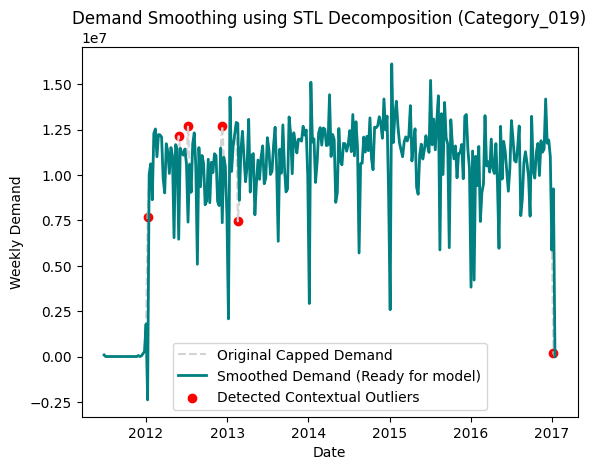

In [33]:
plt.Figure(figsize=(15,6))
plt.plot(cat_19.index, cat_19['Demand_Capped'], label='Original Capped Demand', color='lightgray', linestyle='--')
plt.plot(cat_19.index, cat_19['Demand_Smoothed'], label='Smoothed Demand (Ready for model)', color='teal', linewidth=2)

outliers = cat_19[abs(cat_19['Residual']) > threshold]
plt.scatter(outliers.index, outliers['Demand_Capped'], color='red', label='Detected Contextual Outliers')

plt.title('Demand Smoothing using STL Decomposition (Category_019)')
plt.xlabel('Date')
plt.ylabel('Weekly Demand')
plt.legend()
plt.show()

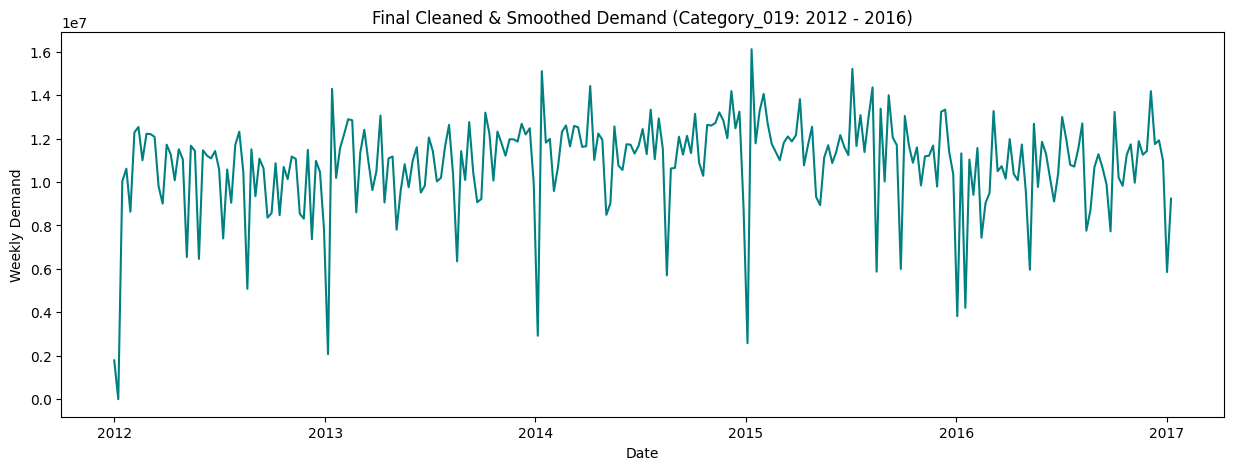

In [34]:
cat_19_clean = cat_19[cat_19.index >= '2012-01-01'].copy()

cat_19_clean = cat_19_clean.iloc[:-1]

cat_19_clean['Demand_Smoothed'] = cat_19_clean['Demand_Smoothed'].clip(lower=0)

plt.figure(figsize=(15, 5))
plt.plot(cat_19_clean.index, cat_19_clean['Demand_Smoothed'], color='teal')
plt.title('Final Cleaned & Smoothed Demand (Category_019: 2012 - 2016)')
plt.xlabel('Date')
plt.ylabel('Weekly Demand')
plt.show()

In [35]:
cat_19['Trend'],cat_19['Seasonality']

(Date
 2011-06-26    1.153624e+06
 2011-07-03    1.296146e+06
 2011-07-10    1.438419e+06
 2011-07-17    1.580432e+06
 2011-07-24    1.722171e+06
                   ...     
 2016-12-18    9.922836e+06
 2016-12-25    9.906896e+06
 2017-01-01    9.890989e+06
 2017-01-08    9.875117e+06
 2017-01-15    9.859277e+06
 Freq: W-SUN, Name: Trend, Length: 291, dtype: float64,
 Date
 2011-06-26   -1.174549e+06
 2011-07-03   -1.071137e+06
 2011-07-10   -1.459768e+06
 2011-07-17   -1.640652e+06
 2011-07-24   -1.426015e+06
                   ...     
 2016-12-18    1.739350e+06
 2016-12-25    7.896988e+05
 2017-01-01   -4.779591e+06
 2017-01-08   -6.382903e+05
 2017-01-15   -9.669878e+06
 Freq: W-SUN, Name: Seasonality, Length: 291, dtype: float64)

In [36]:
weekly_demand

,Product_Category,Date,Demand_Capped
0,Category_001,2011-10-02,28.0
1,Category_001,2011-10-09,0.0
2,Category_001,2011-10-16,0.0
3,Category_001,2011-10-23,0.0
4,Category_001,2011-10-30,0.0
...,...,...,...
8202,Category_033,2016-12-04,200000.0
8203,Category_033,2016-12-11,120000.0
8204,Category_033,2016-12-18,360000.0
8205,Category_033,2016-12-25,280000.0


In [37]:
all_cleaned_categories = []

all_categories = weekly_demand['Product_Category'].unique()

print("Wait in put Data")

for cat in all_categories:

    df_cat = weekly_demand[weekly_demand['Product_Category'] == cat].copy()

    df_cat = df_cat.set_index('Date').asfreq('W', fill_value=0)

    df_cat = df_cat[df_cat.index >= '2012-01-01']
    df_cat = df_cat.iloc[:-1]

    if len(df_cat) >= 104:
        try:
            stl = STL(df_cat['Demand_Capped'], period=52, robust=True)
            result = stl.fit()

            threshold = 3 * result.resid.std()
            df_cat['Demand_Smoothed'] = np.where(
                abs(result.resid) > threshold,
                result.trend + result.seasonal,
                df_cat['Demand_Capped']
            )
        except:
            df_cat['Demand_Smoothed'] = df_cat['Demand_Capped']
    else:
        df_cat['Demand_Smoothed'] = df_cat['Demand_Capped']

    df_cat['Demand_Smoothed'] = df_cat['Demand_Smoothed'].clip(lower=0)

    df_cat['Product_Category'] = cat
    
    all_cleaned_categories.append(df_cat.reset_index())

final_cleaned_df = pd.concat(all_cleaned_categories, ignore_index=True)

print("ประมวลผลเสร็จสิ้น! ข้อมูลทุก Category พร้อมใช้งานแล้ว")
print(f"จำนวนข้อมูลทั้งหมด: {len(final_cleaned_df)} แถว")

display(final_clean_df.sample(5))

Wait in put Data
ประมวลผลเสร็จสิ้น! ข้อมูลทุก Category พร้อมใช้งานแล้ว
จำนวนข้อมูลทั้งหมด: 7994 แถว


NameError: name 'final_clean_df' is not defined

In [ ]:
import os

# ใช้ ../ เพื่อถอยออกจากโฟลเดอร์ notebooks แล้วเข้าไปที่ Data/cleaned
output_path = '../Data/cleaned'

if not os.path.exists(output_path):
    os.makedirs(output_path)

file_name = f'{output_path}/demand_forecast_cleaned.csv'
final_cleaned_df.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"✅ Export ไฟล์สำเร็จ! อยู่ที่: {file_name}")

✅ Export ไฟล์สำเร็จ! อยู่ที่: ../Data/cleaned/demand_forecast_cleaned.csv
